Combining images from MNIST

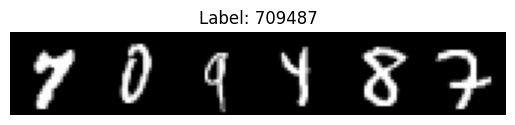

In [283]:
import torch
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import random

# Transform: convert to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load MNIST dataset
mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Function to create a combined image from multiple digits
def create_combined_image(dataset, num_digits=5):
    images = []
    labels = []

    for _ in range(num_digits):
        idx = random.randint(0, len(dataset) - 1)
        img, label = dataset[idx]
        images.append(img)
        labels.append(str(label))

    # Concatenate images horizontally
    combined = torch.cat(images, dim=2)  # dim=2 = width

    return combined, "".join(labels)

# Generate example
combined_img, label_str = create_combined_image(mnist, num_digits=6)
save_image(combined_img, "combined_mnist.png")

# Display image
plt.imshow(combined_img.squeeze(), cmap="gray")
plt.title(f"Label: {label_str}")
plt.axis("off")
plt.show()

**image segmentation**


load and process

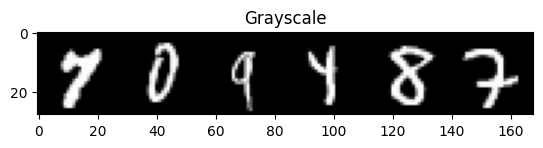

In [284]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('combined_mnist.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.show()

Threshold


In [285]:
# _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

# plt.imshow(thresh, cmap='gray',vmin=0, vmax=255)
# plt.title("Thresholded")
# plt.show()


close small gaps

In [286]:
# kernel = np.ones((1, 1), np.uint8)

# thresh_closed = cv2.morphologyEx(
#     thresh,
#     cv2.MORPH_CLOSE,
#     kernel,
#     iterations=1
# )

# plt.imshow(thresh_closed, cmap='gray')
# plt.title("Tiny Gap Closed")
# plt.show()


Find countours




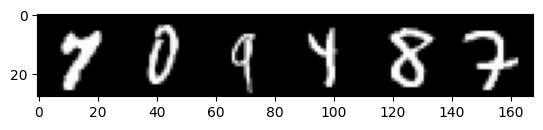

In [287]:
contours, _ = cv2.findContours(gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
plt.imshow(gray, cmap='gray')
plt.show()


Extract bounding boxes

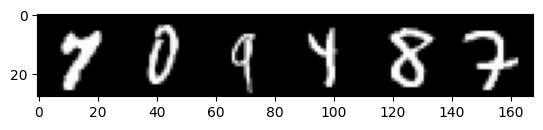

In [288]:
digit_images = []

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)

    # Filter small noise
    area = cv2.contourArea(cnt)
    if cv2.contourArea(cnt) > 50:
        digit = gray[y:y+h, x:x+w]
        digit_images.append((x, digit))
plt.imshow(gray, cmap='gray')
plt.show()

Sort left -> right


In [289]:
digit_images = sorted(digit_images, key=lambda x: x[0])

Display


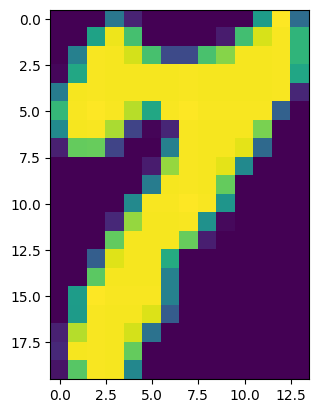

In [290]:
plt.imshow(digit_images[0][1])

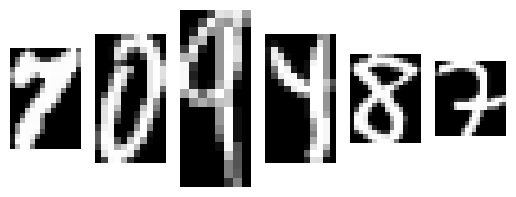

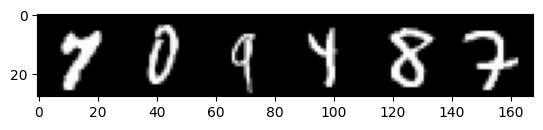

In [293]:
for i, (_, digit) in enumerate(digit_images):
    plt.subplot(1, len(digit_images), i+1)
    plt.imshow(digit, cmap='gray')
    plt.axis('off')

plt.show()

plt.imshow(gray, cmap='gray')
plt.show()